<a href="https://colab.research.google.com/github/rubeng77/MLS-Player-Stats-24/blob/main/MLS_Player_Stats_Anaysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import statsmodels.formula.api as smf
import graphviz

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeRegressor
from sklearn.tree import export_graphviz

from sklearn.metrics import confusion_matrix
from sklearn.metrics import mean_squared_error

from sklearn.linear_model import LinearRegression

Source -
[MLS Player Stats Database](https://www.kaggle.com/datasets/flynn28/mls-player-stats-database)

In [2]:
url = 'https://raw.githubusercontent.com/rubeng77/MLS-Player-Stats-24/refs/heads/main/2024%20MLS%20Player%20Stats%20Database.csv'
mls = pd.read_csv(url)
mls.head()

,id,name,country,position,second_position,club,age,born,matches_played,matches_started,minutes_played,goals,assists,goals_and_assists,yellow_cards,red_cards
0,1,Liel Abada,ISR,Forward,,Charlotte,22.0,2001.0,24,20,"1,637",7,1,8,2,0
1,2,Jose Casas de Abadal,USA,Forward,Defender,Inter Miami,23.0,2000.0,2,0,31,0,0,0,0,0
2,3,Luis Abram,PER,Defender,NaN,Atlanta Utd,27.0,1996.0,19,11,"1,102",0,0,0,2,0
3,4,Lalas Abubakar,GHA,Defender,NaN,Colorado Rapids,29.0,1994.0,18,15,"1,278",0,1,1,3,0
4,5,Kellyn Acosta,USA,Midfielder,NaN,Chicago Fire,28.0,1995.0,34,27,"2,302",3,2,5,6,0


In [3]:
mls.isna().sum()

,0
id,0
name,0
country,2
position,0
second_position,562
club,0
age,2
born,2
matches_played,0
matches_started,0


In [4]:
mls = mls[['name','country','position','club','age','matches_played','matches_started','minutes_played','goals','assists','goals_and_assists']]
mls.head()


,name,country,position,club,age,matches_played,matches_started,minutes_played,goals,assists,goals_and_assists
0,Liel Abada,ISR,Forward,Charlotte,22.0,24,20,"1,637",7,1,8
1,Jose Casas de Abadal,USA,Forward,Inter Miami,23.0,2,0,31,0,0,0
2,Luis Abram,PER,Defender,Atlanta Utd,27.0,19,11,"1,102",0,0,0
3,Lalas Abubakar,GHA,Defender,Colorado Rapids,29.0,18,15,"1,278",0,1,1
4,Kellyn Acosta,USA,Midfielder,Chicago Fire,28.0,34,27,"2,302",3,2,5


In [5]:
mls.isna().sum()

,0
name,0
country,2
position,0
club,0
age,2
matches_played,0
matches_started,0
minutes_played,0
goals,0
assists,0


In [6]:
mls = mls.dropna()
mls.isna().sum()

,0
name,0
country,0
position,0
club,0
age,0
matches_played,0
matches_started,0
minutes_played,0
goals,0
assists,0


Text(0, 0.5, 'Number of players')

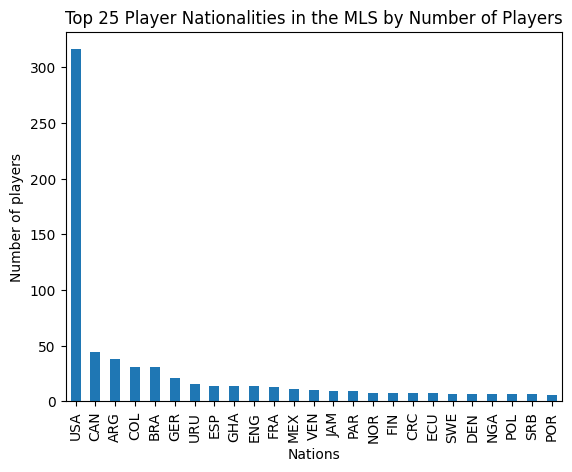

In [7]:
mls['country'].value_counts().head(25).plot(kind = 'bar')
plt.title('Top 25 Player Nationalities in the MLS by Number of Players')
plt.xlabel('Nations')
plt.ylabel('Number of players')



Text(0, 0.5, 'Number of players')

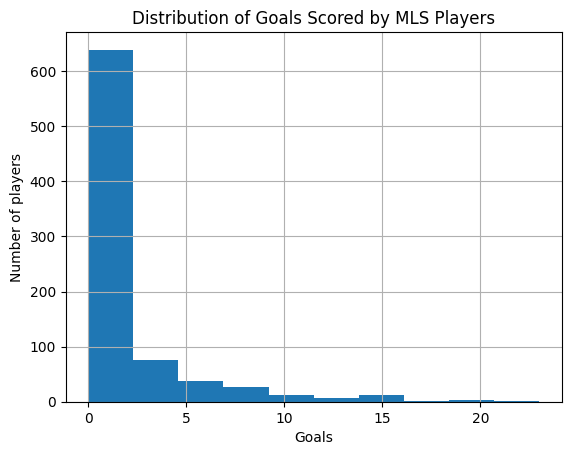

In [8]:
mls['goals'].hist()
plt.title('Distribution of Goals Scored by MLS Players')
plt.xlabel('Goals')
plt.ylabel('Number of players')

Text(0, 0.5, 'Number of players')

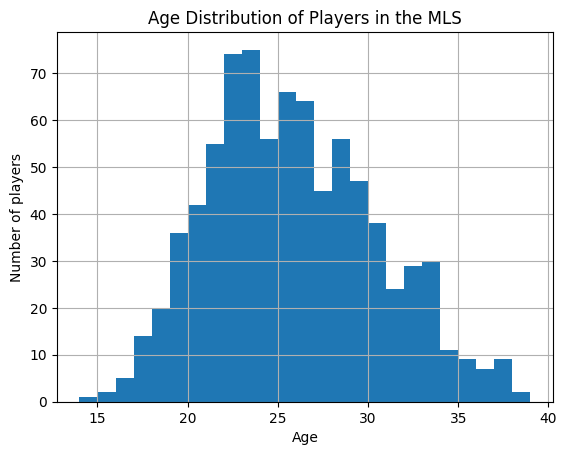

In [9]:
mls['age'].hist(bins = 25)
plt.title('Age Distribution of Players in the MLS')
plt.xlabel('Age')
plt.ylabel('Number of players')

Text(0, 0.5, 'Number of players')

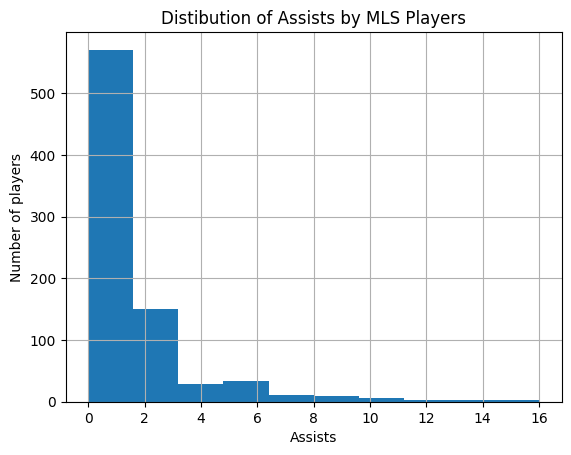

In [10]:
mls['assists'].hist()
plt.title('Distibution of Assists by MLS Players')
plt.xlabel('Assists')
plt.ylabel('Number of players')

In [11]:
mls.columns


Index(['name', 'country', 'position', 'club', 'age', 'matches_played',
       'matches_started', 'minutes_played', 'goals', 'assists',
       'goals_and_assists'],
      dtype='object')

Text(0, 0.5, 'Goal Contributions(Goals + Assists)')

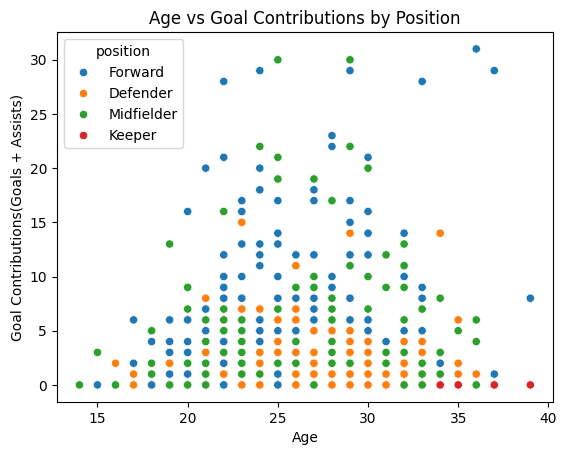

In [12]:
sns.scatterplot(data = mls,x ='age',y ='goals_and_assists',hue = 'position')
plt.title('Age vs Goal Contributions by Position')
plt.xlabel('Age')
plt.ylabel('Goal Contributions(Goals + Assists)')

Text(0, 0.5, 'Age')

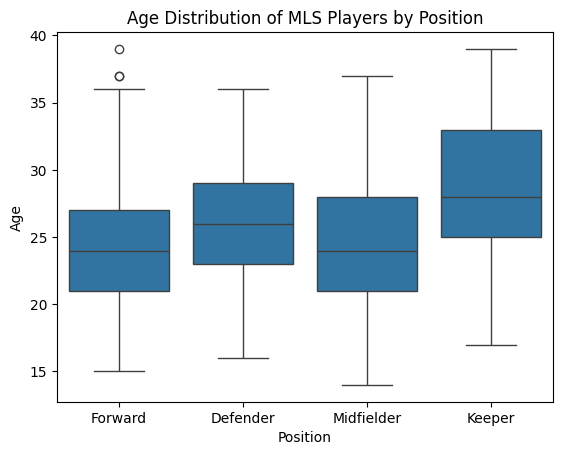

In [13]:
sns.boxplot(data = mls, x='position', y='age')
plt.title('Age Distribution of MLS Players by Position')
plt.xlabel('Position')
plt.ylabel('Age')

In [14]:
mls.dtypes

,0
name,object
country,object
position,object
club,object
age,float64
matches_played,int64
matches_started,int64
minutes_played,object
goals,int64
assists,int64


In [15]:
mls['minutes_played'] = mls['minutes_played'].str.replace(',','')

In [16]:
mls['minutes_played'] = mls['minutes_played'].astype(int)

In [17]:
x = mls[['age','minutes_played']]
y = mls['goals_and_assists']

In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2)

In [19]:
model_dt1 = DecisionTreeRegressor(max_depth = 3)
model_dt1.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=3)

In [20]:
from sklearn.tree import plot_tree

In [21]:
y_test_pred = model_dt1.predict(x_test)

In [22]:
mean_squared_error(y_test, y_test_pred)

22.59286231875926

In [23]:
y_train_pred = model_dt1.predict(x_train)

In [24]:
mean_squared_error(y_train, y_train_pred)

17.793565475658095

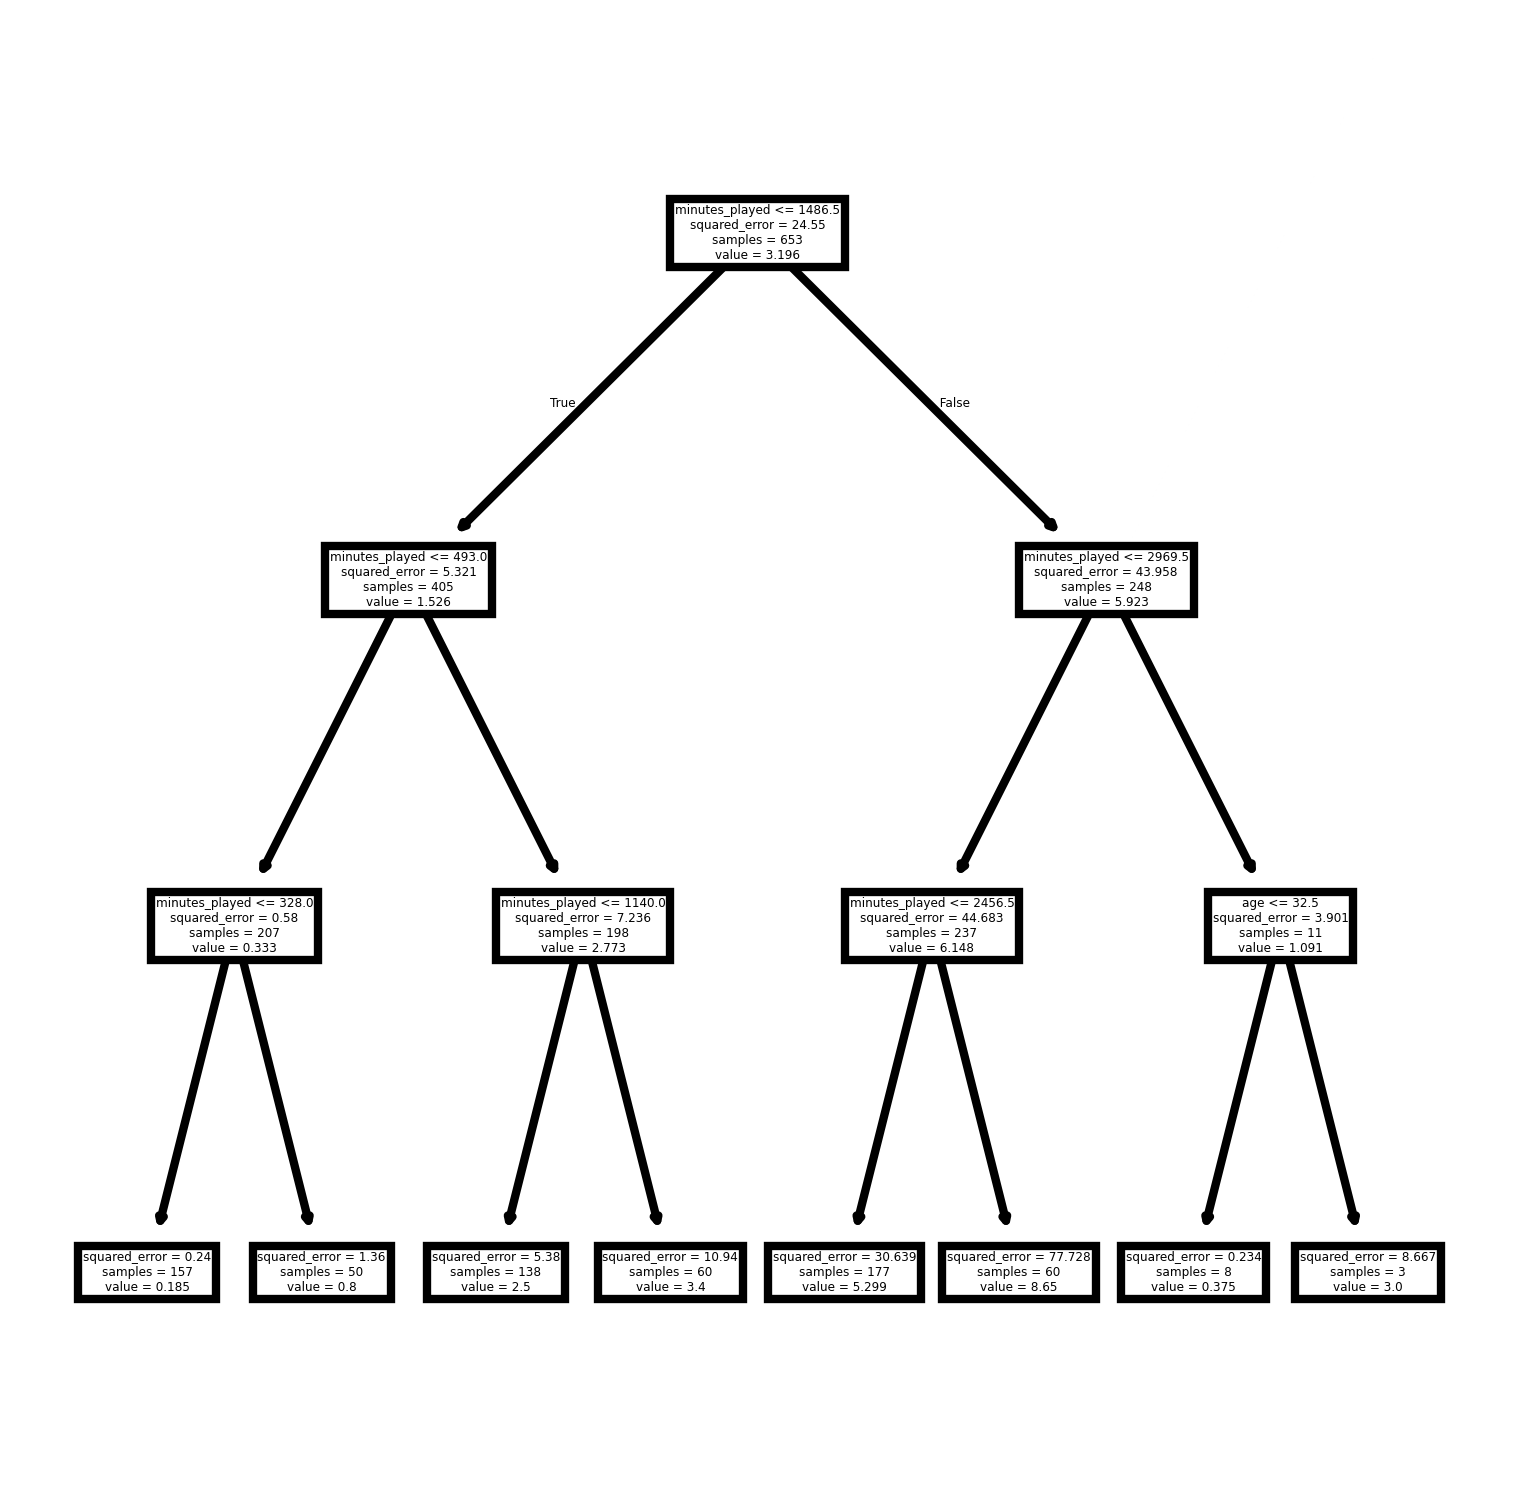

In [25]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (3,3), dpi=600)
_ = plot_tree(model_dt1, feature_names = x.columns)

In [26]:
model_dt2 = DecisionTreeRegressor(max_depth = 4)
model_dt2.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=4)

In [27]:
y_test_pred = model_dt2.predict(x_test)

In [28]:
mean_squared_error(y_test, y_test_pred)

21.676588465469116

In [29]:
y_train_pred = model_dt2.predict(x_train)

In [30]:
mean_squared_error(y_train, y_train_pred)

16.491700485824264

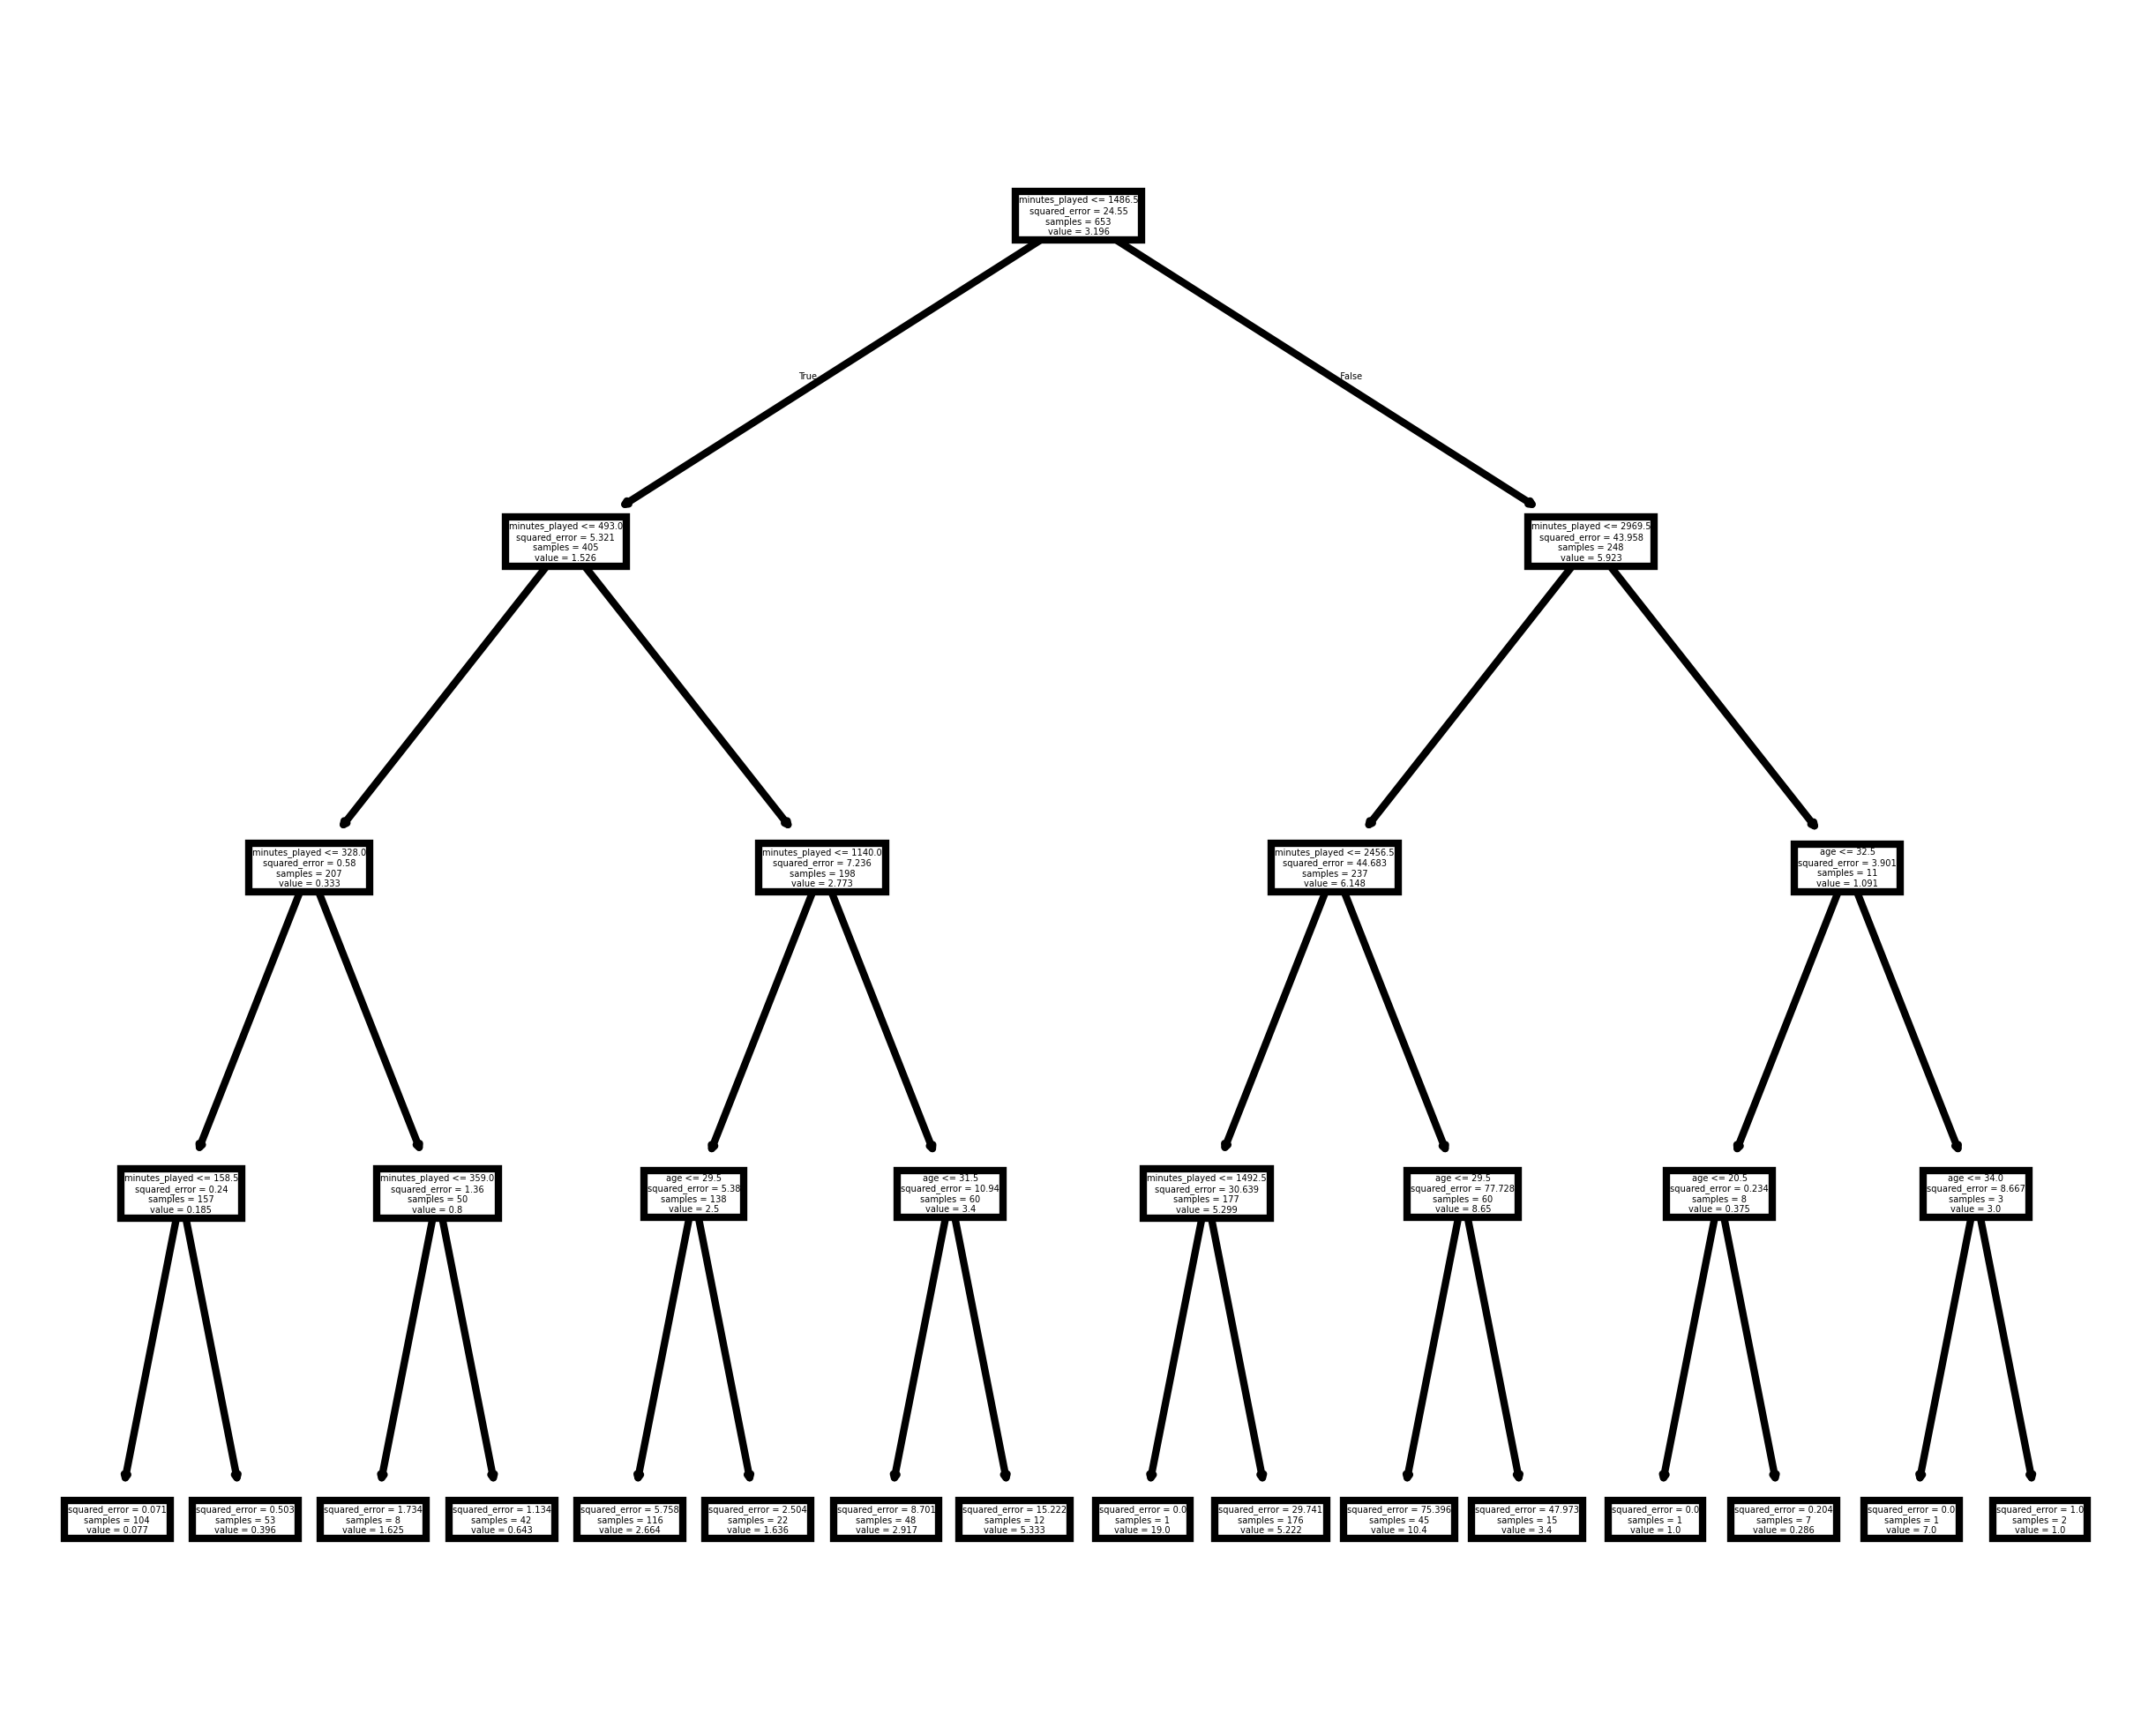

In [31]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (5,4), dpi=600)
_ = plot_tree(model_dt2, feature_names = x.columns)

In [32]:
model_dt3 = DecisionTreeRegressor(max_depth = 2)
model_dt3.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=2)

In [33]:
y_test_pred = model_dt3.predict(x_test)

In [34]:
mean_squared_error(y_test, y_test_pred)

22.165867337622135

In [35]:
y_train_pred = model_dt3.predict(x_train)

In [36]:
mean_squared_error(y_train, y_train_pred)

18.66081629680017

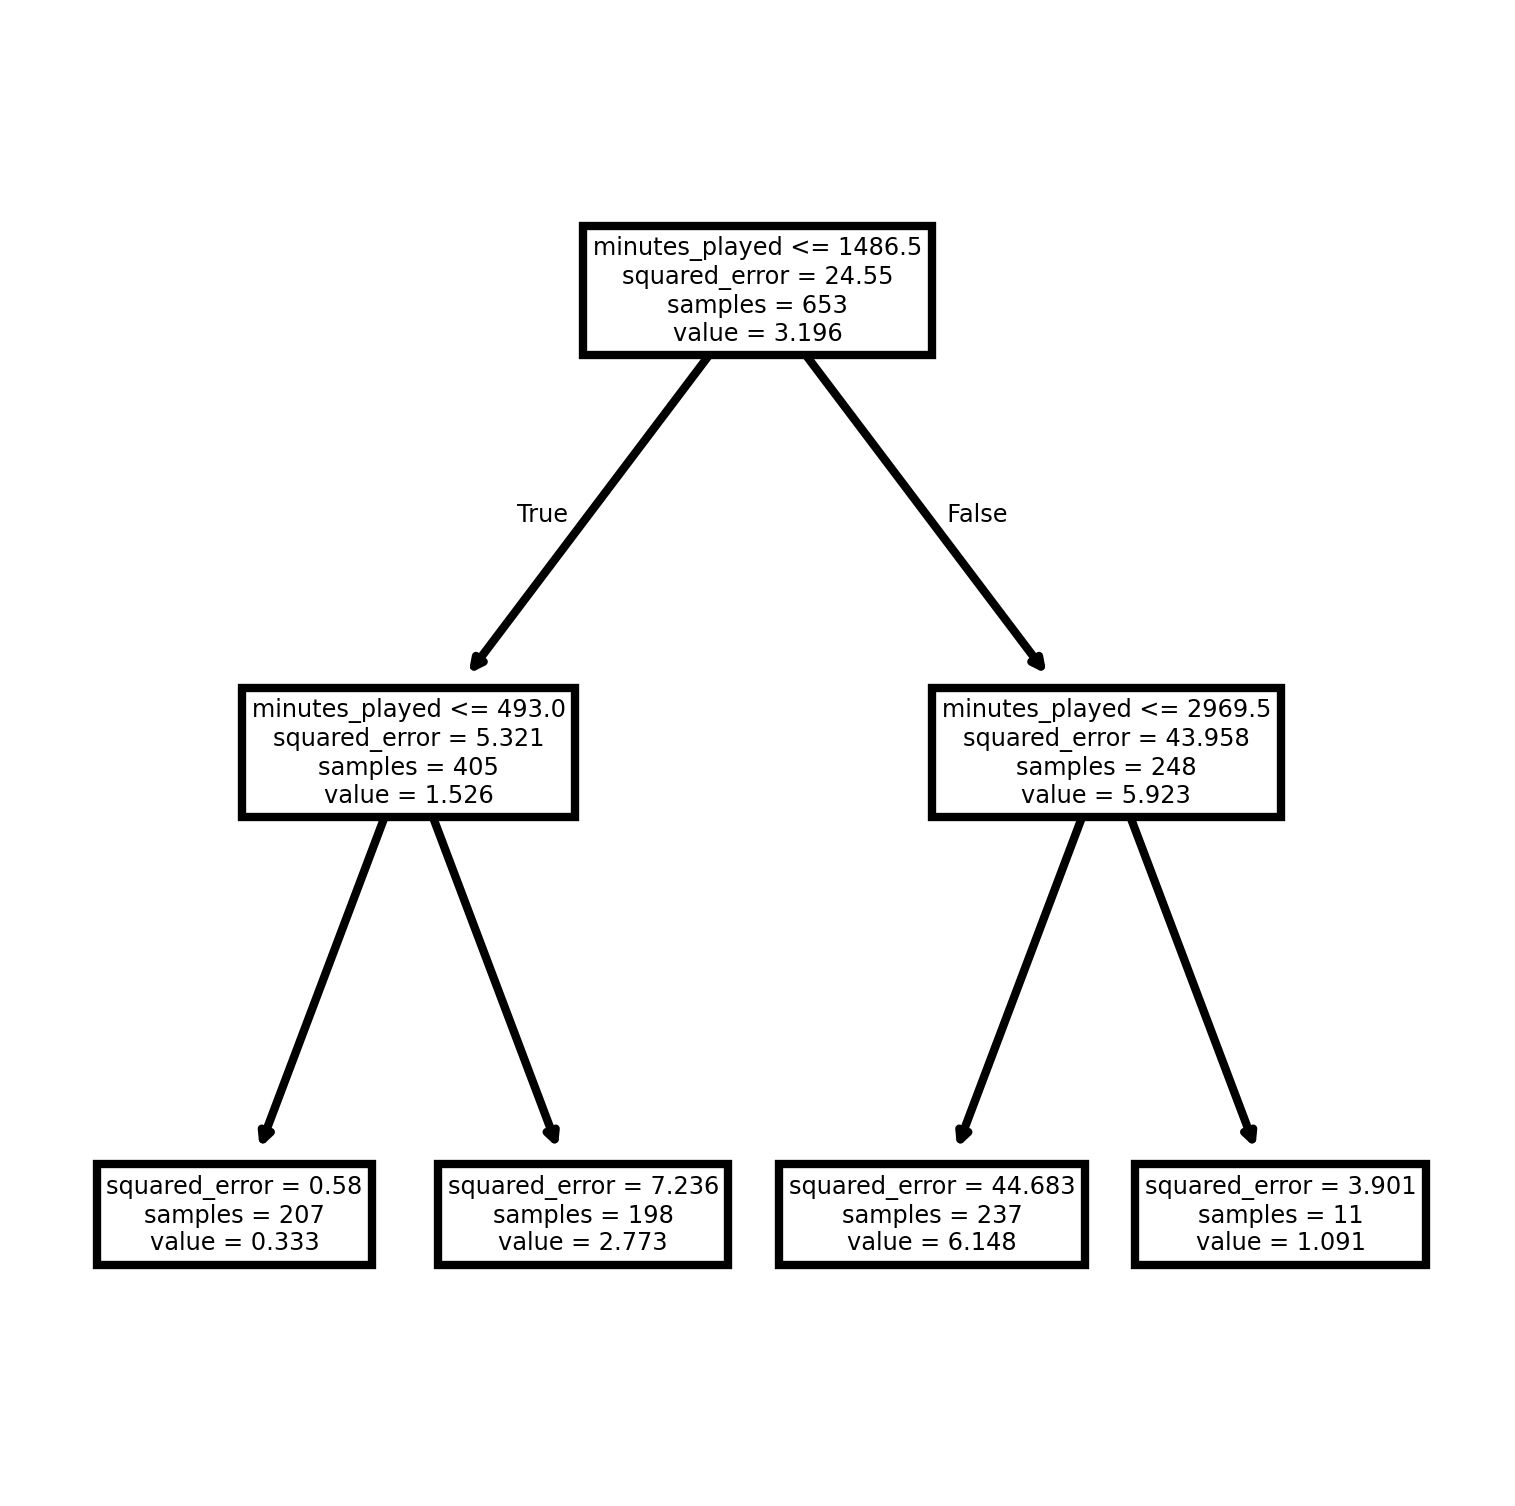

In [37]:
fig, axes = plt.subplots(nrows = 1,ncols = 1,figsize = (3,3), dpi=600)
_ = plot_tree(model_dt3, feature_names = x.columns)

In [38]:
train, test = train_test_split(mls, test_size=0.2)

In [39]:
lrm1 = smf.ols("goals_and_assists ~ age + minutes_played", data=train).fit()
lrm1.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      goals_and_assists   R-squared:                       0.234
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     99.31
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           2.32e-38
Time:                        02:10:23   Log-Likelihood:                -1871.6
No. Observations:                 653   AIC:                             3749.
Df Residuals:                     650   BIC:                             3763.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.6916      0.917      0.755      0.451      -1.108       2.491
age               -0.0255      0.037     -0.689      0.491      -0.098       0.047
minutes_played     0.0027      0.000     13.641      0.000       0.002       0.003
==============================================================================
Omnibus:                      315.659   Durbin-Watson:                   1.979
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2052.899
Skew:                           2.079   Prob(JB):                         0.00
Kurtosis:                      10.626   Cond. No.                     8.15e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 8.15e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [40]:
lrm2 = smf.ols("goals_and_assists ~ minutes_played", data=train).fit()
lrm2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      goals_and_assists   R-squared:                       0.233
Model:                            OLS   Adj. R-squared:                  0.232
Method:                 Least Squares   F-statistic:                     198.3
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           1.66e-39
Time:                        02:10:23   Log-Likelihood:                -1871.9
No. Observations:                 653   AIC:                             3748.
Df Residuals:                     651   BIC:                             3757.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.0895      0.275      0.325      0.745      -0.451       0.630
minutes_played     0.0026      0.000     14.082      0.000       0.002       0.003
==============================================================================
Omnibus:                      313.882   Durbin-Watson:                   1.981
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2021.817
Skew:                           2.069   Prob(JB):                         0.00
Kurtosis:                      10.562   Cond. No.                     2.44e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.44e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [41]:
lrm3 = smf.ols("goals_and_assists ~ age", data=train).fit()
lrm3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      goals_and_assists   R-squared:                       0.015
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     9.756
Date:                Tue, 28 Apr 2026   Prob (F-statistic):            0.00187
Time:                        02:10:24   Log-Likelihood:                -1953.8
No. Observations:                 653   AIC:                             3912.
Df Residuals:                     651   BIC:                             3921.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0151      1.037     -0.015      0.988      -2.051       2.021
age            0.1252      0.040      3.123      0.002       0.047       0.204
==============================================================================
Omnibus:                      377.538   Durbin-Watson:                   2.040
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             2584.386
Skew:                           2.599   Prob(JB):                         0.00
Kurtosis:                      11.245   Cond. No.                         142.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [42]:
lrm1_test = smf.ols("goals_and_assists ~ age + minutes_played", data=test).fit()
lrm1_test.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      goals_and_assists   R-squared:                       0.162
Model:                            OLS   Adj. R-squared:                  0.151
Method:                 Least Squares   F-statistic:                     15.54
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           6.77e-07
Time:                        02:10:24   Log-Likelihood:                -501.18
No. Observations:                 164   AIC:                             1008.
Df Residuals:                     161   BIC:                             1018.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          1.1886      2.342      0.508      0.612      -3.437       5.814
age               -0.0318      0.097     -0.328      0.744      -0.223       0.160
minutes_played     0.0024      0.000      5.367      0.000       0.002       0.003
==============================================================================
Omnibus:                       96.428   Durbin-Watson:                   2.055
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              507.231
Skew:                           2.215   Prob(JB):                    7.18e-111
Kurtosis:                      10.389   Cond. No.                     9.11e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.11e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [43]:
lrm2_test = smf.ols("goals_and_assists ~ minutes_played", data=test).fit()
lrm2_test.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      goals_and_assists   R-squared:                       0.161
Model:                            OLS   Adj. R-squared:                  0.156
Method:                 Least Squares   F-statistic:                     31.14
Date:                Tue, 28 Apr 2026   Prob (F-statistic):           9.90e-08
Time:                        02:10:24   Log-Likelihood:                -501.23
No. Observations:                 164   AIC:                             1006.
Df Residuals:                     162   BIC:                             1013.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          0.4526      0.663      0.683      0.496      -0.856       1.761
minutes_played     0.0023      0.000      5.580      0.000       0.002       0.003
==============================================================================
Omnibus:                       95.062   Durbin-Watson:                   2.056
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              486.021
Skew:                           2.190   Prob(JB):                    2.90e-106
Kurtosis:                      10.207   Cond. No.                     2.58e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.58e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [44]:
lrm3_test = smf.ols("goals_and_assists ~ age", data=test).fit()
lrm3_test.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      goals_and_assists   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     1.932
Date:                Tue, 28 Apr 2026   Prob (F-statistic):              0.166
Time:                        02:10:24   Log-Likelihood:                -514.68
No. Observations:                 164   AIC:                             1033.
Df Residuals:                     162   BIC:                             1040.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -0.0683      2.522     -0.027      0.978      -5.049       4.913
age            0.1380      0.099      1.390      0.166      -0.058       0.334
==============================================================================
Omnibus:                      100.387   Durbin-Watson:                   2.034
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              445.620
Skew:                           2.442   Prob(JB):                     1.72e-97
Kurtosis:                       9.431   Cond. No.                         146.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Text(0, 0.5, 'Goals + Assists')

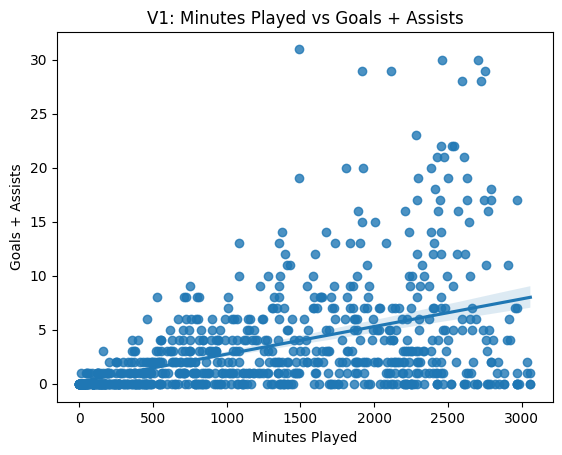

In [45]:
sns.regplot(x='minutes_played', y='goals_and_assists', data=mls)
plt.title('V1: Minutes Played vs Goals + Assists')
plt.xlabel('Minutes Played')
plt.ylabel('Goals + Assists')

Text(0, 0.5, 'Goals + Assists')

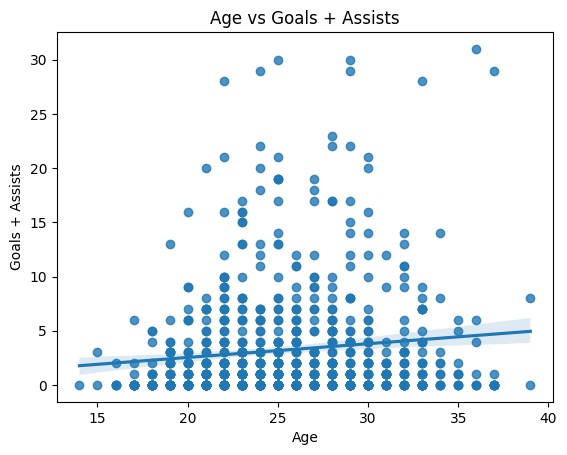

In [46]:
sns.regplot(x='age', y='goals_and_assists', data=mls)
plt.title('Age vs Goals + Assists')
plt.xlabel('Age')
plt.ylabel('Goals + Assists')